# fio — Per-Config Box Plots & Run Statistics

Each `(bs, numjobs)` configuration was run multiple times.  
This notebook shows the per-run spread (box + individual-point overlay) and a  
summary statistics table for **bandwidth**, **IOPS**, and **completion latency**.

- Fixed: `iodepth=16`
- Axes: `bs` ∈ {4k, 16k, 1m, 2m, 4m} × `numjobs` ∈ {4, 8, 16, 32, 64}

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path(".")

BS_ORDER = ["4k", "16k", "1m", "2m", "4m"]
NJ_ORDER = [4, 8, 16, 32, 64]

## Seq Read

In [2]:
def bs_to_bytes(bs: str) -> int:
    bs = bs.lower()
    if bs.endswith("k"):
        return int(bs[:-1]) * 1024
    if bs.endswith("m"):
        return int(bs[:-1]) * 1024 ** 2
    return int(bs)


def parse_file(fpath: Path) -> dict:
    m = re.search(r"fio_\w+_bs(\w+?)_nj(\d+)_iod(\d+)_", fpath.name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))

    with open(fpath) as f:
        d = json.load(f)

    job = d["jobs"][0]
    io  = job["read"] if job["read"]["io_bytes"] > 0 else job["write"]
    clat = io["clat_ns"]
    lat  = io["lat_ns"]
    cp   = clat["percentile"]

    def ms(v): return v / 1e6

    return dict(
        bs             = bs,
        numjobs        = nj,
        iodepth        = iod,
        bw_GiBs        = io["bw_bytes"] / 1024 ** 3,
        iops           = io["iops"],
        lat_mean_ms    = ms(lat["mean"]),
        clat_mean_ms   = ms(clat["mean"]),
        clat_p50_ms    = ms(cp["50.000000"]),
        clat_p90_ms    = ms(cp["90.000000"]),
        clat_p99_ms    = ms(cp["99.000000"]),
        clat_p99_9_ms  = ms(cp["99.900000"]),
        clat_p99_99_ms = ms(cp["99.990000"]),
    )

### Load all seq_read runs (no averaging)

In [3]:
sr_files = [f for f in sorted(RESULTS_DIR.glob("fio_seq_read_*.json")) if f.stat().st_size > 0]
sr_raw = pd.DataFrame([parse_file(f) for f in sr_files])

sr_raw["bs"]       = pd.Categorical(sr_raw["bs"],                  categories=BS_ORDER, ordered=True)
sr_raw["numjobs"]  = pd.Categorical(sr_raw["numjobs"].astype(int), categories=NJ_ORDER, ordered=True)
sr_raw["bs_bytes"] = sr_raw["bs"].apply(bs_to_bytes)
sr_raw = sr_raw.sort_values(["bs_bytes", "numjobs"]).reset_index(drop=True)

n_total = sum(1 for _ in RESULTS_DIR.glob("fio_seq_read_*.json"))
print(f"Loaded {len(sr_files)} seq_read JSON files ({n_total - len(sr_files)} empty skipped)")
sr_raw.head(10)

Loaded 44 seq_read JSON files (1 empty skipped)


,bs,numjobs,iodepth,bw_GiBs,iops,lat_mean_ms,clat_mean_ms,clat_p50_ms,clat_p90_ms,clat_p99_ms,clat_p99_9_ms,clat_p99_99_ms,bs_bytes
0,4k,4,16,0.696877,182682.121965,0.350009,0.346000,0.358400,0.501760,0.602112,0.905216,9.895936,4096
1,4k,4,16,0.709672,186036.282729,0.343653,0.339806,0.354304,0.493568,0.593920,1.011712,9.371648,4096
2,4k,8,16,1.413529,370548.124198,0.345090,0.341125,0.354304,0.493568,0.593920,1.204224,10.289152,4096
3,4k,8,16,1.392353,364997.083382,0.350280,0.346351,0.358400,0.497664,0.602112,1.236992,10.289152,4096
4,4k,16,16,2.730135,715688.388527,0.357347,0.353340,0.362496,0.505856,0.651264,1.613824,10.551296,4096
5,4k,16,16,2.479478,649980.166997,0.393442,0.389552,0.387072,0.569344,0.929792,1.794048,10.682368,4096
6,4k,32,16,2.588414,678537.198760,0.754128,0.749868,0.675840,1.171456,1.548288,4.947968,12.255232,4096
7,4k,32,16,1.756655,460496.600227,1.111183,1.106830,1.105920,1.482752,1.859584,7.372800,12.910592,4096
8,4k,64,16,2.929759,768018.697819,1.332440,1.328077,1.318912,1.646592,2.605056,9.633792,16.318464,4096
9,4k,64,16,3.105965,814210.158815,1.256665,1.252497,1.236992,1.564672,2.441216,9.764864,17.170432,4096


### Run counts per configuration

In [4]:
run_counts = (
    sr_raw.groupby(["bs", "numjobs"], observed=True)
    .size()
    .unstack("numjobs")
    .reindex(BS_ORDER)
)
print("Runs per (bs, numjobs) configuration:")
display(run_counts)

Runs per (bs, numjobs) configuration:


numjobs,4,8,16,32,64
bs,,,,,
4k,2,2,2,2,2
16k,2,2,2,2,2
1m,2,2,2,2,2
2m,2,2,2,2,1
4m,1,1,1,1,1


### Summary statistics per configuration

In [5]:
summary = sr_raw.groupby(["bs", "numjobs"], observed=True).agg(
    n             = ("bw_GiBs",      "count"),
    bw_mean       = ("bw_GiBs",      "mean"),
    bw_std        = ("bw_GiBs",      "std"),
    bw_min        = ("bw_GiBs",      "min"),
    bw_max        = ("bw_GiBs",      "max"),
    iops_mean     = ("iops",         "mean"),
    iops_std      = ("iops",         "std"),
    clat_mean     = ("clat_mean_ms", "mean"),
    clat_std      = ("clat_mean_ms", "std"),
    clat_p99_mean = ("clat_p99_ms",  "mean"),
    clat_p99_std  = ("clat_p99_ms",  "std"),
).reset_index()
summary["bs"] = pd.Categorical(summary["bs"], categories=BS_ORDER, ordered=True)
summary = summary.sort_values(["bs", "numjobs"]).reset_index(drop=True)
display(summary.round(3))

,bs,numjobs,n,bw_mean,bw_std,bw_min,bw_max,iops_mean,iops_std,clat_mean,clat_std,clat_p99_mean,clat_p99_std
0,4k,4,2,0.703,0.009,0.697,0.710,184359.202,2371.750,0.343,0.004,0.598,0.006
1,4k,8,2,1.403,0.015,1.392,1.414,367772.604,3925.179,0.344,0.004,0.598,0.006
2,4k,16,2,2.605,0.177,2.479,2.730,682834.278,46462.729,0.371,0.026,0.791,0.197
3,4k,32,2,2.173,0.588,1.757,2.588,569516.899,154177.986,0.928,0.252,1.704,0.220
4,4k,64,2,3.018,0.125,2.930,3.106,791114.428,32662.295,1.290,0.053,2.523,0.116
5,16k,4,2,2.822,0.272,2.630,3.015,184968.809,17833.796,0.342,0.033,0.725,0.070
6,16k,8,2,2.847,0.649,2.388,3.306,186555.286,42541.138,0.699,0.161,1.401,0.278
7,16k,16,2,3.224,0.238,3.056,3.393,211307.164,15612.104,1.209,0.090,2.068,0.110
8,16k,32,2,3.692,0.021,3.678,3.707,241973.418,1355.597,2.109,0.012,4.301,1.193
9,16k,64,2,3.871,0.324,3.642,4.100,253666.704,21234.373,4.042,0.340,6.291,0.510


### Box plots — Bandwidth, IOPS, Mean latency, P99 latency

One figure per metric. Each figure has five subplots (one per block size);  
x-axis = `numjobs`, each dot = one run, box spans IQR, whiskers reach min/max.

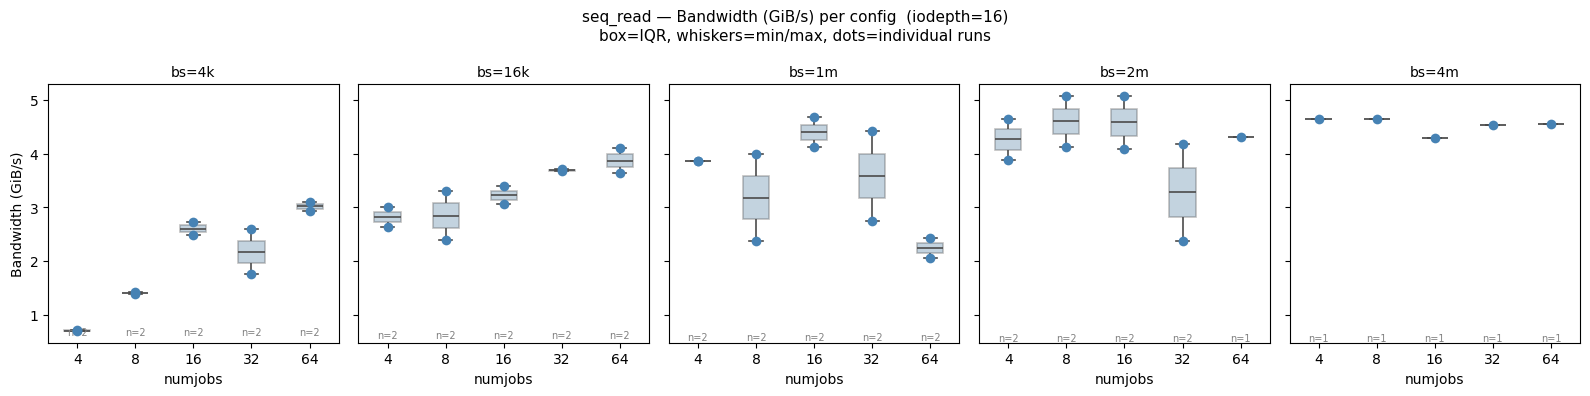

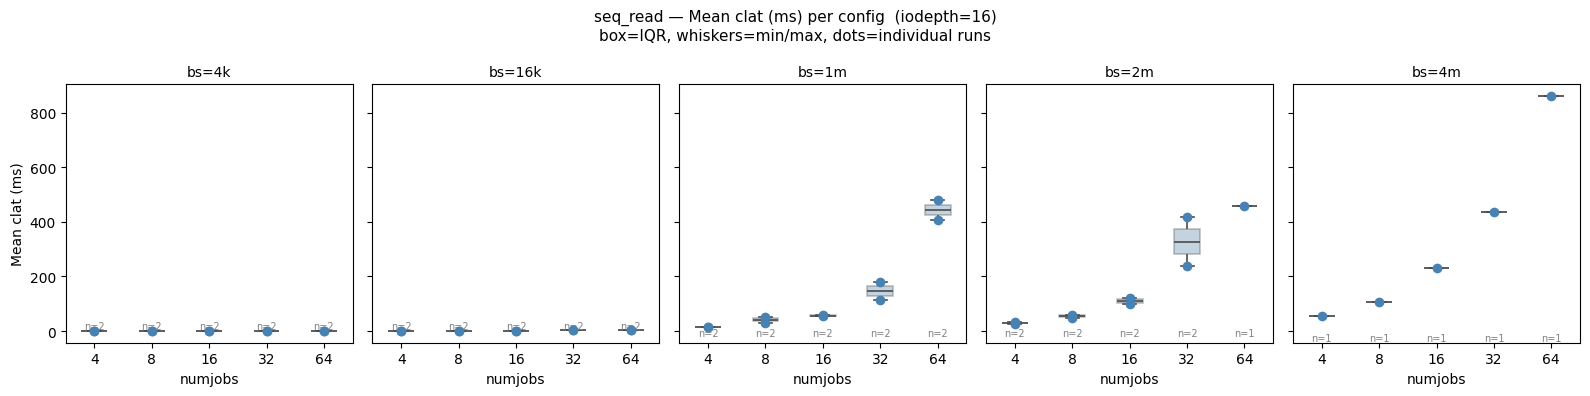

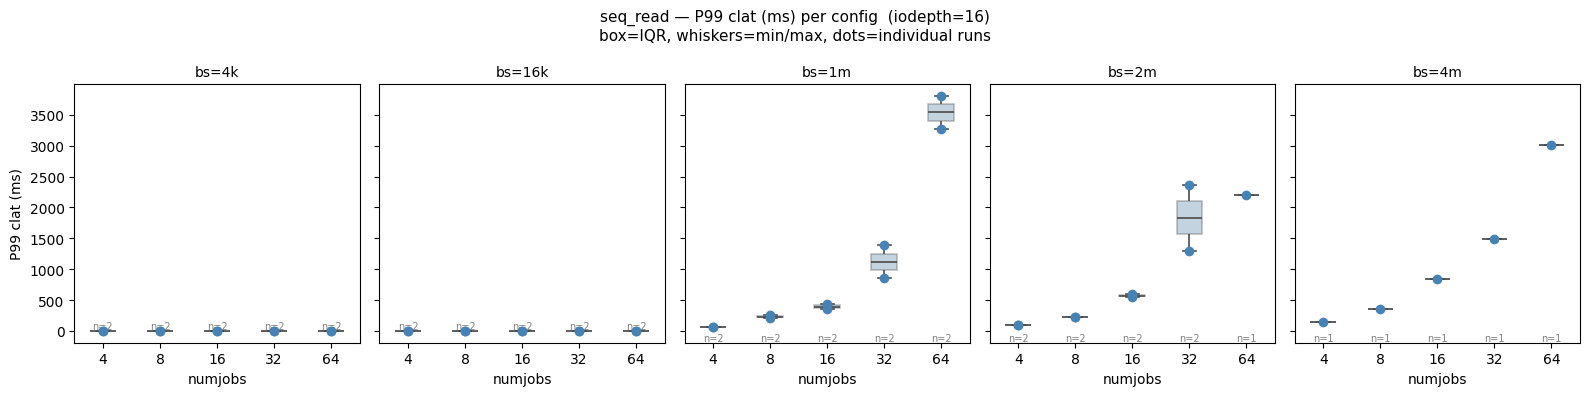

In [8]:
bp_metrics = [
    ("bw_GiBs",      "Bandwidth (GiB/s)"),
    ("clat_mean_ms", "Mean clat (ms)"),
    ("clat_p99_ms",  "P99 clat (ms)"),
]

for metric, ylabel in bp_metrics:
    fig, axes = plt.subplots(1, len(BS_ORDER), figsize=(16, 4), sharey=True)
    fig.suptitle(
        f"seq_read — {ylabel} per config  (iodepth=16)\n"
        "box=IQR, whiskers=min/max, dots=individual runs",
        fontsize=11,
    )

    for ax, bs in zip(axes, BS_ORDER):
        sub = sr_raw[sr_raw["bs"] == bs]

        sns.boxplot(
            data=sub, x="numjobs", y=metric, ax=ax,
            color="steelblue", width=0.45, fliersize=0, linewidth=1.2,
            boxprops=dict(alpha=0.35),
        )
        sns.stripplot(
            data=sub, x="numjobs", y=metric, ax=ax,
            color="steelblue", size=7, jitter=False, zorder=5,
        )

        # n= annotation below each group
        ymin = ax.get_ylim()[0]
        for i, nj in enumerate(NJ_ORDER):
            n = len(sub[sub["numjobs"] == nj])
            if n > 0:
                ax.text(i, ymin, f"n={n}", ha="center", va="bottom",
                        fontsize=7, color="gray")

        ax.set_title(f"bs={bs}", fontsize=10)
        ax.set_xlabel("numjobs")
        ax.set_ylabel(ylabel if ax is axes[0] else "")
        ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"boxplot_seqread_{metric}.pdf", bbox_inches="tight", dpi=150)
    plt.show()